# Weather Forecasting with a Vanilla RNN

This notebook builds a **Recurrent Neural Network (RNN)** to predict the next day's weather from historical weather data.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
try:
    from google.colab import files
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
except Exception:
    filename = "weather.csv"
    df = pd.read_csv(filename)

df.head()

Saving london_weather.csv to london_weather.csv


,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [3]:
df.columns = [c.strip().lower() for c in df.columns]
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.sort_values("date").reset_index(drop=True)

candidate_cols = [
    "mean_temp", "temperature", "temp", "min_temp", "max_temp",
    "humidity", "rainfall", "precipitation", "cloud_cover", "sunshine"
]

numeric_cols = [c for c in candidate_cols if c in df.columns]
if len(numeric_cols) < 2:
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df = df[numeric_cols].copy()
df = df.ffill().bfill()

df.head()

,mean_temp,min_temp,max_temp,precipitation,cloud_cover,sunshine
0,-4.1,-7.5,2.3,0.4,2.0,7.0
1,-2.6,-7.5,1.6,0.0,6.0,1.7
2,-2.8,-7.2,1.3,0.0,5.0,0.0
3,-2.6,-6.5,-0.3,0.0,8.0,0.0
4,-0.8,-1.4,5.6,0.0,6.0,2.0


In [4]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

SEQ_LEN = 7

def create_sequences(data, seq_len, target_index=0):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len, target_index])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, SEQ_LEN, target_index=0)

split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

X_train.shape, X_test.shape

(torch.Size([12267, 7, 6]), torch.Size([3067, 7, 6]))

In [5]:
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(WeatherDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(WeatherDataset(X_test, y_test), batch_size=32, shuffle=False)

In [6]:
class WeatherRNN(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out.squeeze(-1)

model = WeatherRNN(input_size=X_train.shape[2], hidden_size=64)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
epochs = 20
losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

Epoch 1/20 - Loss: 0.0067
Epoch 2/20 - Loss: 0.0015
Epoch 3/20 - Loss: 0.0010
Epoch 4/20 - Loss: 0.0010
Epoch 5/20 - Loss: 0.0009
Epoch 6/20 - Loss: 0.0009
Epoch 7/20 - Loss: 0.0009
Epoch 8/20 - Loss: 0.0009
Epoch 9/20 - Loss: 0.0009
Epoch 10/20 - Loss: 0.0009
Epoch 11/20 - Loss: 0.0009
Epoch 12/20 - Loss: 0.0009
Epoch 13/20 - Loss: 0.0009
Epoch 14/20 - Loss: 0.0009
Epoch 15/20 - Loss: 0.0009
Epoch 16/20 - Loss: 0.0009
Epoch 17/20 - Loss: 0.0009
Epoch 18/20 - Loss: 0.0009
Epoch 19/20 - Loss: 0.0009
Epoch 20/20 - Loss: 0.0009


In [8]:
model.eval()
preds, actuals = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb)
        preds.extend(out.numpy())
        actuals.extend(yb.numpy())

mse = mean_squared_error(actuals, preds)
mae = mean_absolute_error(actuals, preds)

print("MSE:", mse)
print("MAE:", mae)

MSE: 0.0010570699882981461
MAE: 0.02447730190578252


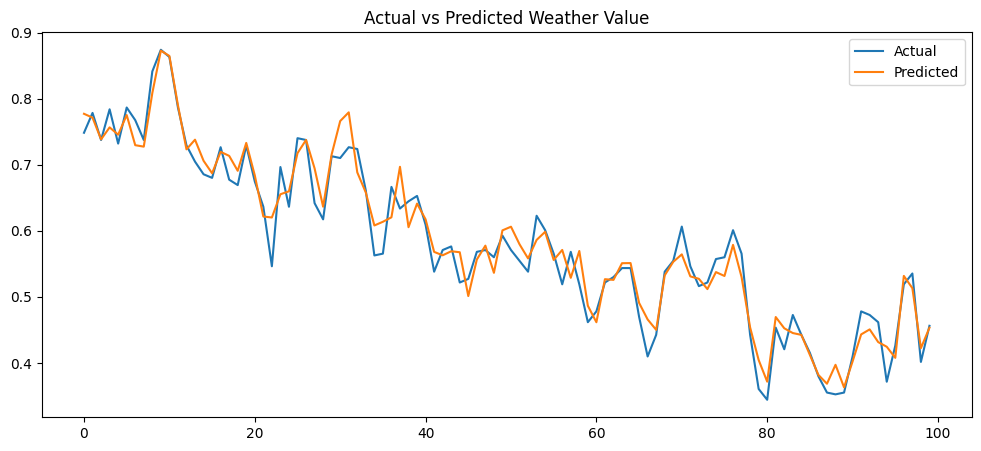

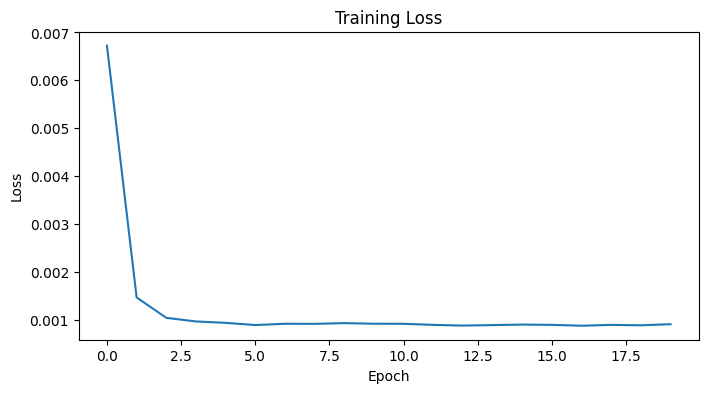

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(actuals[:100], label="Actual")
plt.plot(preds[:100], label="Predicted")
plt.title("Actual vs Predicted Weather Value")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [10]:
last_seq = X_test[-1].unsqueeze(0)

with torch.no_grad():
    next_pred_scaled = model(last_seq).item()

temp_arr = np.zeros((1, len(numeric_cols)))
temp_arr[0, 0] = next_pred_scaled
next_day_prediction = scaler.inverse_transform(temp_arr)[0, 0]

print("Predicted Next Day Value:", next_day_prediction)

Predicted Next Day Value: 3.309256690740586
